# Pixel-wise Thermal Analysis

This notebook replicates the analysis pipeline of `thermal_analysis.ipynb` at the **individual pixel level**.
Instead of using ROI-averaged features (one scalar per layer per specimen), we use per-pixel temperature series from `feature_table_pixel_<config>.csv`.

**Goal:** identify which pixels in the ROI carry the most information about `peso_rottura_kg`, and whether per-pixel features outperform the spatial mean.

---

## Dataset
- **Paused specimens:** `feature_table_pixel_ROI_wide_2_6_depth_1_2.csv` — 10 specimens × N pixels, 6 layers
- **STD specimens:** `feature_table_pixel_STD_ROI_wide_3_10_depth_1_3.csv` — 2 STD specimens × N pixels, 22–29 layers

## ROI geometry: `wide_2_6 / depth_1_2`
The ROI is built **in front of the nozzle** in the direction of movement.
The nozzle is the spatial reference but lies **outside** the ROI:
- `wide_2_6`: ROI starts 2 px to the right of the nozzle tip, ends 6 px to the right → **5 columns** (col offset +2 … +6)
- `depth_1_2`: ROI starts 1 px below the nozzle tip, ends 2 px below → **2 rows** (row offset +1 … +2)
- Total: **10 pixels** per specimen

## Color coding
- 🔵 Blue `#636EFA`: direct IR measurements (`T1_px`–`T6_px`, `bed_temp_C`)
- 🔴 Red `#EF553B`: WLS-fitted / extrapolated (`T0`, `heating_rate_t0`, `alpha`, `A`)
- ⚫ Grey `#888888`: control variable (`pausa_s`)
- 🟣 Purple `#AB63FA`: STD specimens
- Pause groups: 10s=`#636EFA`, 30s=`#00CC96`, 60s=`#FFA15A`, 90s=`#EF553B`

In [15]:
# ── SECTION 0: Imports & Paths ────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE = r"C:\Users\tomga\Desktop\Lab Data science\Dataset_giusti"
PIXEL_CSV   = os.path.join(BASE, "feature_tables", "output",
                           "feature_table_pixel_ROI_wide_2_6_depth_1_2.csv")
STD_CSV     = os.path.join(BASE, "feature_tables", "output",
                           "feature_table_pixel_STD_ROI_wide_3_10_depth_1_3.csv")
ROI_CSV     = os.path.join(BASE, "feature_tables", "output",
                           "feature_table_roi_ROI_wide_2_6_depth_1_2.csv")
OUTPUT_DIR  = os.path.join(BASE, "Modelli_feature_tables", "Notebooks", "output",
                           "pixelwise")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Color palettes ────────────────────────────────────────────────────────────
PAUSE_COLORS = {10: '#636EFA', 30: '#00CC96', 60: '#FFA15A', 90: '#EF553B'}
COLOR_DIRECT = '#636EFA'   # blue  — direct IR
COLOR_MODEL  = '#EF553B'   # red   — WLS model
COLOR_CTRL   = '#888888'   # grey  — control
COLOR_STD    = '#AB63FA'   # purple — STD

print('Paths OK. Output dir:', OUTPUT_DIR)

Paths OK. Output dir: C:\Users\tomga\Desktop\Lab Data science\Dataset_giusti\Modelli_feature_tables\Notebooks\output\pixelwise


## Section 1 — Data Loading & Exploration

In [16]:
# ── Load pixel feature tables ─────────────────────────────────────────────────
df_px  = pd.read_csv(PIXEL_CSV)
df_std = pd.read_csv(STD_CSV)
df_roi = pd.read_csv(ROI_CSV)   # ROI-aggregated for final comparison

# Filter: only specimens with pausa (not STD rows if present), fit_ok=True
df_px = df_px[df_px['fit_ok'] == True].copy()

# Pixel geometry info — derived directly from data, no hardcoding
n_rows   = df_px['pixel_row'].max() + 1
n_cols   = df_px['pixel_col'].max() + 1
n_pixels = n_rows * n_cols
specimens = sorted(df_px['specimen'].unique())

print(f'Paused dataset: {df_px.shape[0]} rows | {len(specimens)} specimens | {n_rows}x{n_cols} = {n_pixels} pixels/specimen')
print(f'STD dataset:    {df_std.shape[0]} rows')
print(f'Pause durations: {sorted(df_px["pausa_s"].unique())} s')
print(f'\nColumns: {list(df_px.columns)}')

Paused dataset: 99 rows | 10 specimens | 2x5 = 10 pixels/specimen
STD dataset:    48 rows
Pause durations: [np.int64(10), np.int64(30), np.int64(60), np.int64(90)] s

Columns: ['specimen', 'pausa_s', 'peso_rottura_kg', 'pixel_row', 'pixel_col', 'pixel_id', 'T1_px', 'T2_px', 'T3_px', 'T4_px', 'T5_px', 'T6_px', 'delta_T_px', 'T_mean_px', 'T_std_px', 'T_max_px', 'T_min_px', 'fit_ok', 'fit_error', 'T0', 'A', 'alpha', 'T_inf', 't_star', 'heating_rate_t0', 'sigma_T0', 'sigma_A', 'sigma_alpha', 'bed_temp_C', 'bed_temp_std_C']


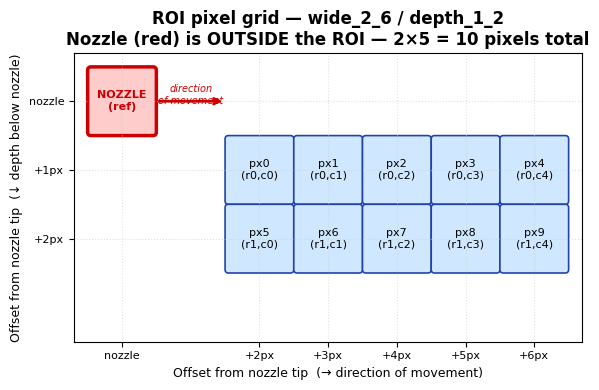

In [17]:
# ── ROI grid visualisation ────────────────────────────────────────────────────
# The nozzle is the geometric reference but lies OUTSIDE and to the LEFT of the ROI.
# ROI wide_2_6 / depth_1_2:
#   columns: ROI starts 2px RIGHT of nozzle (col_offset=2) and ends 6px right (col_offset=6)
#            → pixel_col 0 corresponds to nozzle_x + 2px
#            → pixel_col 4 corresponds to nozzle_x + 6px
#   rows:    ROI starts 1px BELOW nozzle (row_offset=1) and ends 2px below (row_offset=2)
#            → pixel_row 0 corresponds to nozzle_y + 1px
#            → pixel_row 1 corresponds to nozzle_y + 2px
# The nozzle itself is drawn OUTSIDE the grid at position (-2, -1) relative to ROI origin.

# ROI config params (from filename: wide_2_6 / depth_1_2)
WIDE_LEFT  = 2   # px from nozzle to left edge of ROI  (col_offset start)
WIDE_RIGHT = 6   # px from nozzle to right edge of ROI (col_offset end)
DEPTH_TOP  = 1   # px from nozzle to top edge of ROI   (row_offset start)
DEPTH_BOT  = 2   # px from nozzle to bottom edge of ROI (row_offset end)

# In the plot coordinate system: nozzle at (0, 0), ROI pixels start at (WIDE_LEFT, DEPTH_TOP)
fig, ax = plt.subplots(figsize=(10, 4))

# Draw ROI pixels
for r in range(n_rows):
    for c in range(n_cols):
        pid = r * n_cols + c
        # Real position relative to nozzle
        plot_x = WIDE_LEFT + c   # x offset from nozzle
        plot_y = DEPTH_TOP + r   # y offset from nozzle (down = positive)
        rect = mpatches.FancyBboxPatch((plot_x - 0.45, plot_y - 0.45), 0.9, 0.9,
                                       boxstyle='round,pad=0.05',
                                       linewidth=1.2, edgecolor='#2244AA',
                                       facecolor='#D0E8FF')
        ax.add_patch(rect)
        ax.text(plot_x, plot_y,
                f'px{pid}\n(r{r},c{c})',
                ha='center', va='center', fontsize=8)

# Draw nozzle OUTSIDE the ROI (at position 0,0 — to the left and above)
nozzle_rect = mpatches.FancyBboxPatch((-0.45, -0.45), 0.9, 0.9,
                                       boxstyle='round,pad=0.05',
                                       linewidth=2.5, edgecolor='#CC0000',
                                       facecolor='#FFCCCC')
ax.add_patch(nozzle_rect)
ax.text(0, 0, 'NOZZLE\n(ref)', ha='center', va='center',
        fontsize=8, fontweight='bold', color='#CC0000')

# Arrow from nozzle toward ROI (movement direction = right)
ax.annotate('', xy=(WIDE_LEFT - 0.5, 0),
            xytext=(0.5, 0),
            arrowprops=dict(arrowstyle='->', color='#CC0000', lw=2))
ax.text(WIDE_LEFT / 2, -0.25, 'direction\nof movement',
        ha='center', va='top', fontsize=7, color='#CC0000', style='italic')

# Axis labels showing real offsets from nozzle
ax.set_xlim(-0.7, WIDE_RIGHT + 0.7)
ax.set_ylim(-0.7, DEPTH_BOT + DEPTH_TOP + 0.5)
ax.invert_yaxis()

# X ticks: offset from nozzle
xtick_positions = [0] + [WIDE_LEFT + c for c in range(n_cols)]
xtick_labels    = ['nozzle'] + [f'+{WIDE_LEFT+c}px' for c in range(n_cols)]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, fontsize=8)

ytick_positions = [0] + [DEPTH_TOP + r for r in range(n_rows)]
ytick_labels    = ['nozzle'] + [f'+{DEPTH_TOP+r}px' for r in range(n_rows)]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels, fontsize=8)

ax.set_xlabel('Offset from nozzle tip  (→ direction of movement)', fontsize=9)
ax.set_ylabel('Offset from nozzle tip  (↓ depth below nozzle)', fontsize=9)
ax.set_title(
    f'ROI pixel grid — wide_{WIDE_LEFT}_{WIDE_RIGHT} / depth_{DEPTH_TOP}_{DEPTH_BOT}\n'
    f'Nozzle (red) is OUTSIDE the ROI — {n_rows}×{n_cols} = {n_pixels} pixels total',
    fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, linestyle=':', color='#ccc', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S1_roi_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Temperature Profiles per Pixel

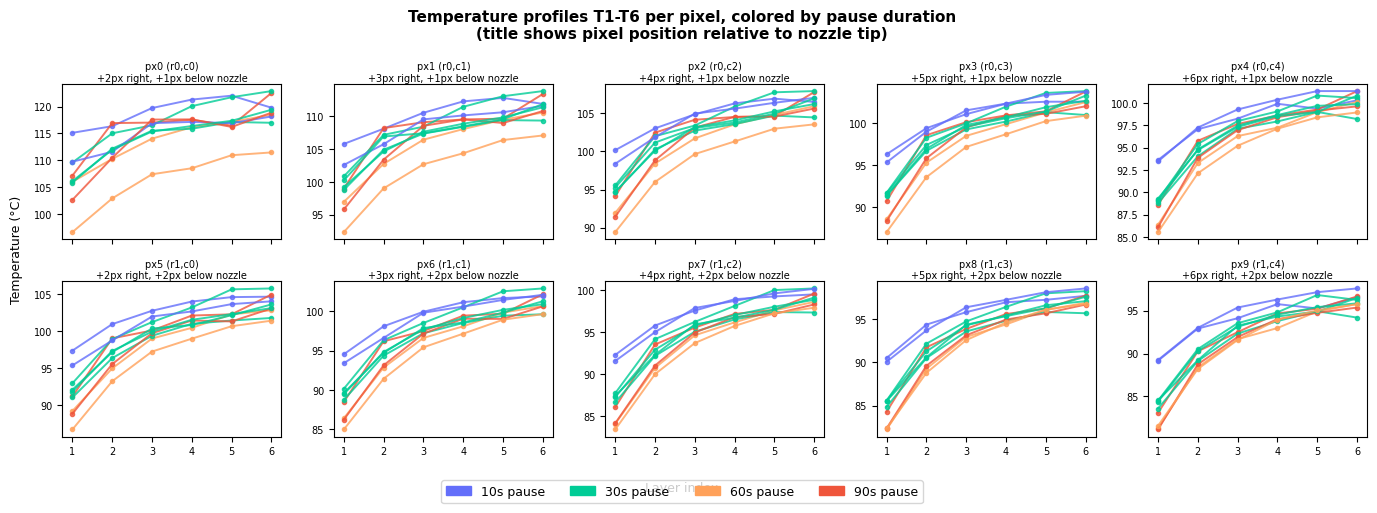

In [18]:
# ── T1_px..T6_px per pixel, colored by pause group ────────────────────────────
T_COLS = [f'T{k}_px' for k in range(1, 7)]
layers = list(range(1, 7))
pixel_ids = sorted(df_px['pixel_id'].unique())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.8, n_rows * 2.5),
                         sharex=True, sharey=False)
if n_rows == 1:
    axes = axes.reshape(1, -1)

for r in range(n_rows):
    for c in range(n_cols):
        ax = axes[r, c]
        pid = r * n_cols + c
        sub = df_px[df_px['pixel_id'] == pid]
        for _, row in sub.iterrows():
            color = PAUSE_COLORS.get(int(row['pausa_s']), '#999')
            ax.plot(layers, row[T_COLS].values, marker='o', ms=3,
                    color=color, alpha=0.8, lw=1.4)
        # Label includes physical offset from nozzle
        x_off = WIDE_LEFT + c
        y_off = DEPTH_TOP + r
        ax.set_title(f'px{pid} (r{r},c{c})\n+{x_off}px right, +{y_off}px below nozzle',
                     fontsize=7, pad=2)
        ax.tick_params(labelsize=7)

# Legend
handles = [mpatches.Patch(color=v, label=f'{k}s pause') for k, v in PAUSE_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('Layer index', fontsize=9)
fig.supylabel('Temperature (°C)', fontsize=9)
fig.suptitle('Temperature profiles T1-T6 per pixel, colored by pause duration\n'
             '(title shows pixel position relative to nozzle tip)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S2_temp_profiles_per_pixel.png'),
            dpi=150, bbox_inches='tight')
plt.show()

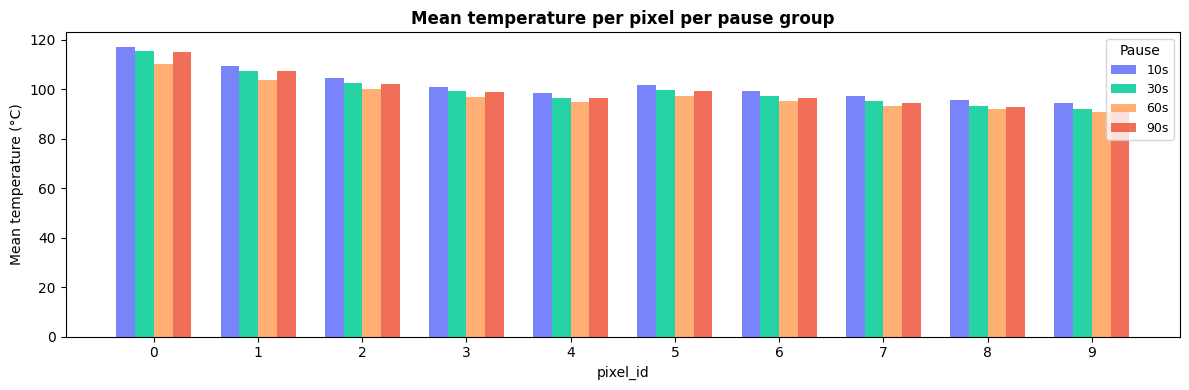

In [19]:
# ── Mean temperature per pixel per pause group (bar chart) ────────────────────
mean_by_pixel_pause = (df_px.groupby(['pixel_id', 'pausa_s'])
                             ['T_mean_px'].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 4))
width  = 0.18
pauses = sorted(df_px['pausa_s'].unique())
x      = np.array(pixel_ids)
for i, p in enumerate(pauses):
    sub = mean_by_pixel_pause[mean_by_pixel_pause['pausa_s'] == p]
    sub = sub.set_index('pixel_id').reindex(pixel_ids)
    ax.bar(x + (i - 1.5) * width, sub['T_mean_px'].values,
           width=width, color=PAUSE_COLORS[p], label=f'{p}s', alpha=0.85)

ax.set_xlabel('pixel_id', fontsize=10)
ax.set_ylabel('Mean temperature (°C)', fontsize=10)
ax.set_title('Mean temperature per pixel per pause group', fontweight='bold')
ax.set_xticks(pixel_ids)
ax.legend(title='Pause', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S2_mean_temp_by_pixel_pause.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Univariate R² per Pixel × Feature

In [20]:
# ── Compute R²(peso_rottura_kg ~ feature) for each pixel × feature ───────────
FEATURES_DIRECT = [f'T{k}_px' for k in range(1, 7)] + ['delta_T_px', 'T_mean_px', 'T_std_px']
FEATURES_MODEL  = ['T0', 'A', 'alpha', 'heating_rate_t0', 'T_inf']
FEATURES_ALL    = FEATURES_DIRECT + FEATURES_MODEL

feat_colors = {f: COLOR_DIRECT for f in FEATURES_DIRECT}
feat_colors.update({f: COLOR_MODEL for f in FEATURES_MODEL})

r2_matrix = pd.DataFrame(index=pixel_ids, columns=FEATURES_ALL, dtype=float)

for pid in pixel_ids:
    sub = df_px[df_px['pixel_id'] == pid].dropna(subset=['peso_rottura_kg'])
    for feat in FEATURES_ALL:
        if feat not in sub.columns:
            continue
        valid = sub[[feat, 'peso_rottura_kg']].dropna()
        if len(valid) < 3:
            r2_matrix.loc[pid, feat] = np.nan
            continue
        X = valid[[feat]].values
        y = valid['peso_rottura_kg'].values
        r2_matrix.loc[pid, feat] = r2_score(y, LinearRegression().fit(X, y).predict(X))

print('R² matrix shape:', r2_matrix.shape)
print(r2_matrix.round(3))

R² matrix shape: (10, 14)
   T1_px  T2_px  T3_px  T4_px  T5_px  T6_px  delta_T_px  T_mean_px  T_std_px  \
0  0.240  0.001  0.039  0.027  0.040  0.027       0.689      0.035     0.613   
1  0.286  0.005  0.094  0.080  0.090  0.003       0.539      0.083     0.419   
2  0.364  0.055  0.140  0.141  0.128  0.001       0.497      0.161     0.429   
3  0.435  0.131  0.236  0.206  0.182  0.014       0.486      0.253     0.455   
4  0.508  0.310  0.205  0.353  0.142  0.070       0.485      0.359     0.519   
5  0.393  0.152  0.278  0.167  0.143  0.014       0.535      0.221     0.469   
6  0.450  0.193  0.372  0.246  0.209  0.047       0.521      0.306     0.466   
7  0.503  0.301  0.419  0.387  0.280  0.134       0.503      0.407     0.483   
8  0.567  0.413  0.452  0.414  0.321  0.180       0.537      0.483     0.539   
9  0.591  0.572  0.425  0.458  0.160  0.311       0.498      0.543     0.577   

      T0      A  alpha  heating_rate_t0  T_inf  
0  0.401  0.598  0.140            0.225  0.0

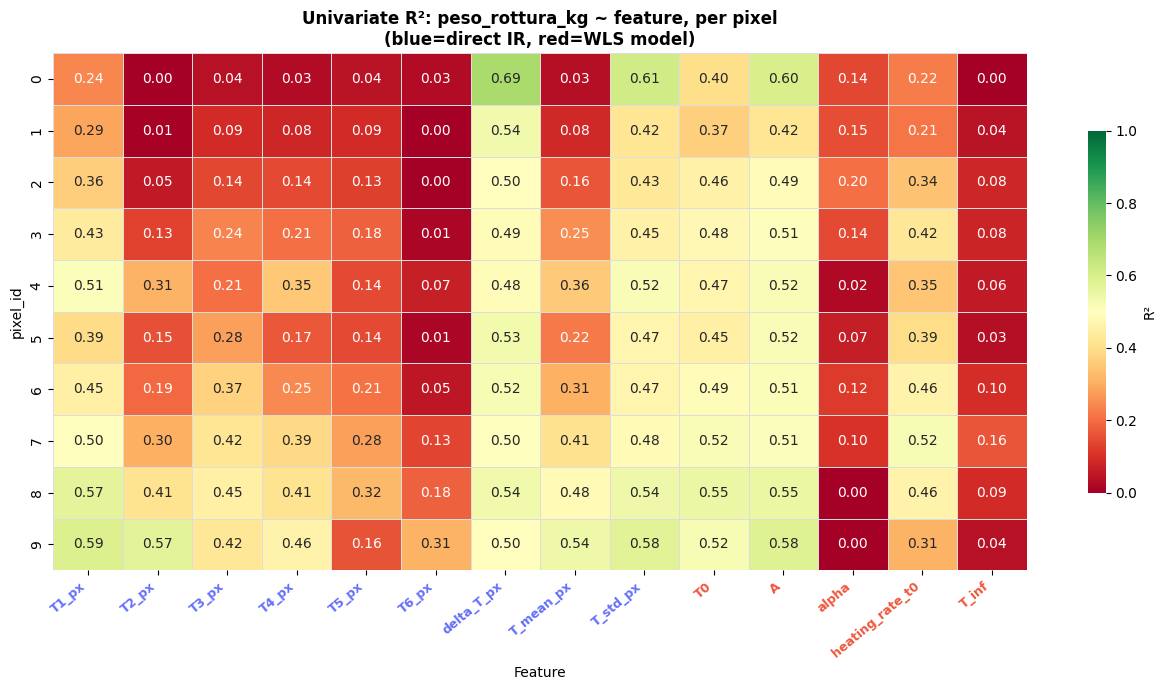

In [21]:
# ── Heatmap: R² pixel × feature ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(len(FEATURES_ALL) * 0.85 + 1, n_pixels * 0.55 + 1.5))
r2_plot = r2_matrix.astype(float)
sns.heatmap(r2_plot, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='#ddd',
            cbar_kws={'label': 'R²', 'shrink': 0.7})
for tick, feat in zip(ax.get_xticklabels(), FEATURES_ALL):
    tick.set_color(feat_colors.get(feat, 'black'))
    tick.set_fontweight('bold')
ax.set_title('Univariate R²: peso_rottura_kg ~ feature, per pixel\n'
             '(blue=direct IR, red=WLS model)', fontweight='bold')
ax.set_xlabel('Feature', fontsize=10)
ax.set_ylabel('pixel_id', fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S3_r2_heatmap_pixel_feature.png'),
            dpi=150, bbox_inches='tight')
plt.show()

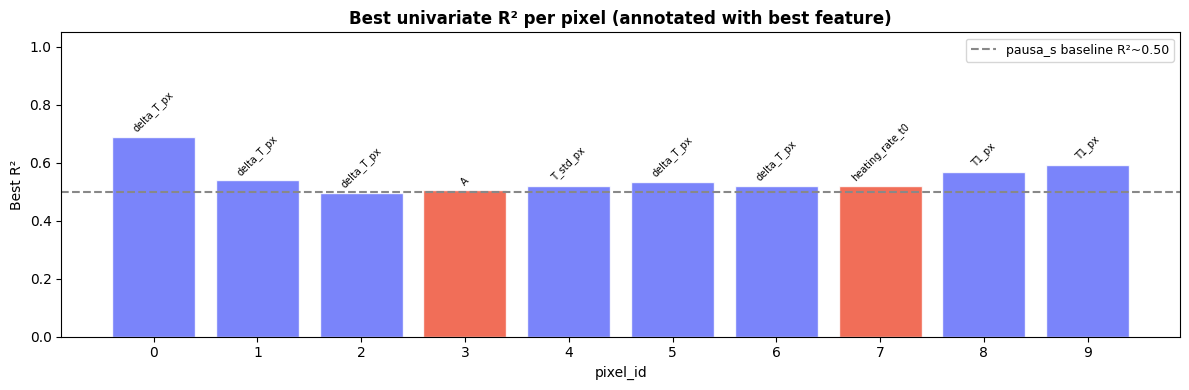

In [22]:
# ── R² bar chart: best feature per pixel ─────────────────────────────────────
best_r2   = r2_matrix.max(axis=1)
best_feat = r2_matrix.idxmax(axis=1)
bar_colors = [feat_colors.get(f, '#999') for f in best_feat]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(pixel_ids, best_r2.values, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, feat in zip(bars, best_feat):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, feat,
            ha='center', va='bottom', fontsize=7, rotation=45)
ax.axhline(0.50, color=COLOR_CTRL, lw=1.5, ls='--', label='pausa_s baseline R²~0.50')
ax.set_xlabel('pixel_id', fontsize=10)
ax.set_ylabel('Best R²', fontsize=10)
ax.set_title('Best univariate R² per pixel (annotated with best feature)',
             fontweight='bold')
ax.set_xticks(pixel_ids)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S3_best_r2_per_pixel.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Mediation Analysis per Pixel (Baron & Kenny)

In [23]:
# ── Baron & Kenny mediation per pixel × feature ───────────────────────────────
# DeltaR2 = R²(Y ~ X+M) - R²(Y ~ M) : unique contribution of pausa_s given M
# Close to 0 → M is a strong mediator of pausa_s → peso_rottura_kg

def compute_r2(X_cols, y_col, data):
    valid = data[X_cols + [y_col]].dropna()
    if len(valid) < 3:
        return np.nan
    X = valid[X_cols].values
    y = valid[y_col].values
    return r2_score(y, LinearRegression().fit(X, y).predict(X))

pausa_specimens = df_px.drop_duplicates('specimen')[['specimen', 'pausa_s', 'peso_rottura_kg']]
r2_pausa_base = compute_r2(['pausa_s'], 'peso_rottura_kg', pausa_specimens)
print(f'Baseline R²(peso_rottura ~ pausa_s) = {r2_pausa_base:.3f}')

mediation = {}
for pid in pixel_ids:
    sub_px = df_px[df_px['pixel_id'] == pid]
    mediation[pid] = {}
    for feat in FEATURES_ALL:
        if feat not in sub_px.columns:
            continue
        data_m = sub_px[['pausa_s', 'peso_rottura_kg', feat]].dropna()
        if len(data_m) < 3:
            mediation[pid][feat] = np.nan
            continue
        r2_xm    = compute_r2(['pausa_s', feat], 'peso_rottura_kg', data_m)
        r2_m_only = compute_r2([feat], 'peso_rottura_kg', data_m)
        mediation[pid][feat] = r2_xm - r2_m_only

med_matrix = pd.DataFrame(mediation).T
med_matrix.index.name = 'pixel_id'
print('\nMediation DeltaR² matrix (lower = stronger mediation):')
print(med_matrix.round(3))

Baseline R²(peso_rottura ~ pausa_s) = 0.342

Mediation DeltaR² matrix (lower = stronger mediation):
          T1_px  T2_px  T3_px  T4_px  T5_px  T6_px  delta_T_px  T_mean_px  \
pixel_id                                                                    
0         0.212  0.445  0.401  0.411  0.421  0.437       0.002      0.404   
1         0.088  0.352  0.271  0.267  0.252  0.352       0.003      0.260   
2         0.039  0.288  0.232  0.225  0.214  0.343       0.000      0.192   
3         0.015  0.220  0.162  0.174  0.166  0.329       0.002      0.125   
4         0.004  0.119  0.164  0.090  0.211  0.322       0.000      0.077   
5         0.034  0.207  0.116  0.206  0.203  0.329       0.003      0.150   
6         0.011  0.171  0.057  0.156  0.142  0.302       0.002      0.090   
7         0.001  0.099  0.039  0.076  0.098  0.246       0.000      0.040   
8         0.001  0.055  0.016  0.057  0.078  0.225       0.001      0.016   
9         0.003  0.018  0.021  0.061  0.197  0.206   

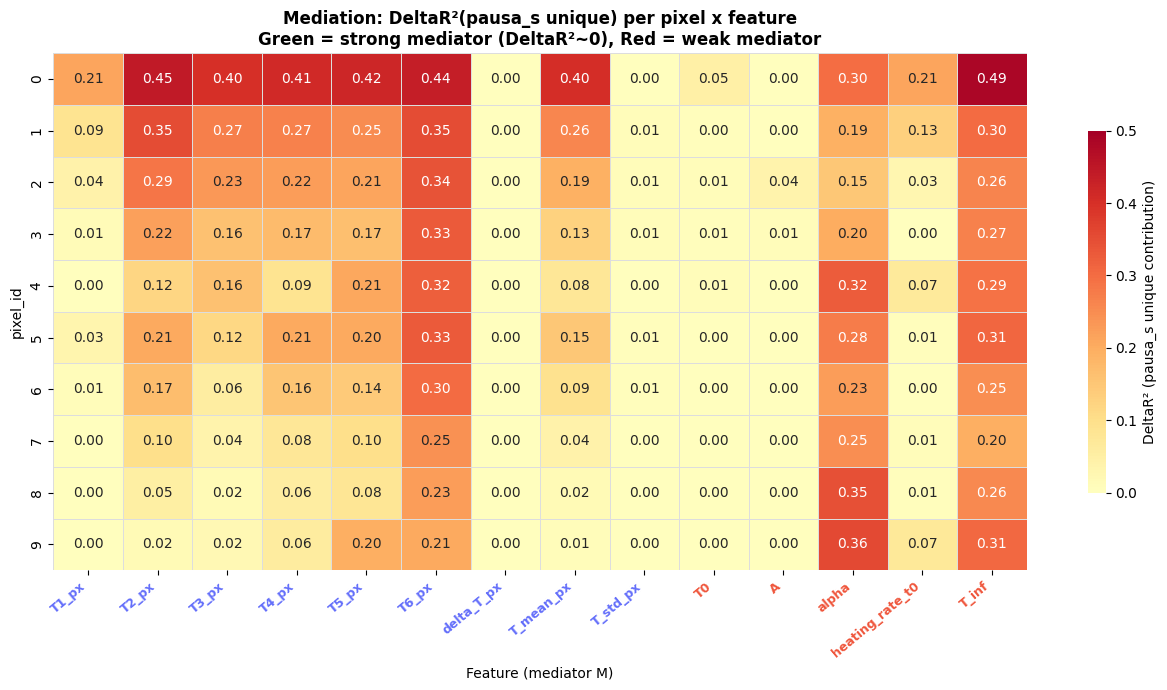

In [24]:
# ── Mediation heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(len(FEATURES_ALL) * 0.85 + 1, n_pixels * 0.55 + 1.5))
med_plot = med_matrix[FEATURES_ALL].astype(float)
sns.heatmap(med_plot, ax=ax, cmap='RdYlGn_r', center=0, vmin=0, vmax=0.5,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='#ddd',
            cbar_kws={'label': 'DeltaR² (pausa_s unique contribution)', 'shrink': 0.7})
for tick, feat in zip(ax.get_xticklabels(), FEATURES_ALL):
    tick.set_color(feat_colors.get(feat, 'black'))
    tick.set_fontweight('bold')
ax.set_title('Mediation: DeltaR²(pausa_s unique) per pixel x feature\n'
             'Green = strong mediator (DeltaR²~0), Red = weak mediator', fontweight='bold')
ax.set_xlabel('Feature (mediator M)', fontsize=10)
ax.set_ylabel('pixel_id', fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S4_mediation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Pixel Ranking & Informativity Map

In [25]:
# ── Pixel ranking ─────────────────────────────────────────────────────────────
ranking = pd.DataFrame({
    'pixel_id':      pixel_ids,
    'best_r2':       [r2_matrix.loc[pid].max() for pid in pixel_ids],
    'best_feat':     [r2_matrix.loc[pid].idxmax() for pid in pixel_ids],
    'min_delta_r2':  [med_matrix.loc[pid].min() for pid in pixel_ids],
    'best_med_feat': [med_matrix.loc[pid].idxmin() for pid in pixel_ids],
    'pixel_row':     [pid // n_cols for pid in pixel_ids],
    'pixel_col':     [pid % n_cols for pid in pixel_ids],
    'x_offset_from_nozzle': [WIDE_LEFT + (pid % n_cols) for pid in pixel_ids],
    'y_offset_from_nozzle': [DEPTH_TOP + (pid // n_cols) for pid in pixel_ids],
})
ranking = ranking.sort_values('best_r2', ascending=False).reset_index(drop=True)
print('Pixel ranking by best R²:')
print(ranking.to_string(index=False))
ranking.to_csv(os.path.join(OUTPUT_DIR, 'pixel_ranking.csv'), index=False)

Pixel ranking by best R²:
 pixel_id  best_r2       best_feat  min_delta_r2 best_med_feat  pixel_row  pixel_col  x_offset_from_nozzle  y_offset_from_nozzle
        0 0.688985      delta_T_px      0.001648    delta_T_px          0          0                     2                     1
        9 0.591370           T1_px      0.000377            T0          1          4                     6                     2
        8 0.566940           T1_px      0.000212             A          1          3                     5                     2
        1 0.538891      delta_T_px      0.002515             A          0          1                     3                     1
        5 0.534915      delta_T_px      0.000579            T0          1          0                     2                     2
        6 0.520975      delta_T_px      0.001677    delta_T_px          1          1                     3                     2
        7 0.520101 heating_rate_t0      0.000023    delta_T_px         

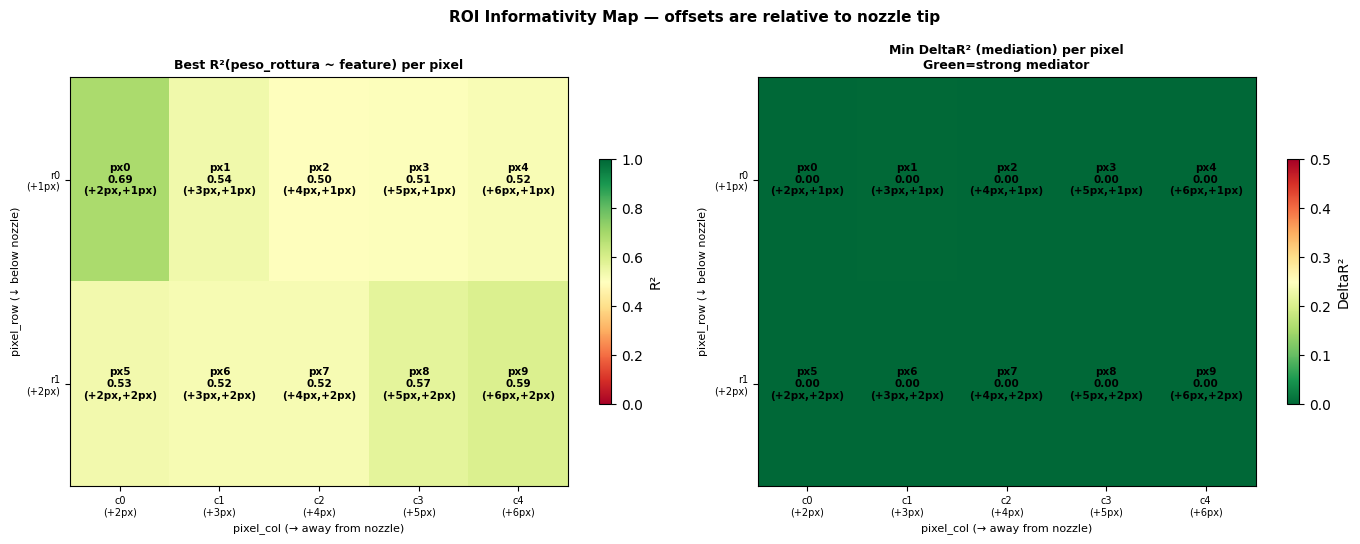

In [26]:
# ── Informativity map: R² and mediation on ROI grid ──────────────────────────
# Grid is placed at nozzle-relative offsets (x from +WIDE_LEFT, y from +DEPTH_TOP)
r2_grid    = np.full((n_rows, n_cols), np.nan)
delta_grid = np.full((n_rows, n_cols), np.nan)
for pid in pixel_ids:
    r = pid // n_cols
    c = pid % n_cols
    r2_grid[r, c]    = r2_matrix.loc[pid].max()
    delta_grid[r, c] = med_matrix.loc[pid].min()

fig, axes = plt.subplots(1, 2, figsize=(14, max(3, n_rows * 2 + 1.5)))

for ax_i, (grid, cmap, title, clabel, vmax) in enumerate([
    (r2_grid,    'RdYlGn',   'Best R²(peso_rottura ~ feature) per pixel', 'R²',    1.0),
    (delta_grid, 'RdYlGn_r', 'Min DeltaR² (mediation) per pixel\nGreen=strong mediator', 'DeltaR²', 0.5),
]):
    ax = axes[ax_i]
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=vmax, aspect='auto')
    for r in range(n_rows):
        for c in range(n_cols):
            pid = r * n_cols + c
            val = grid[r, c]
            ax.text(c, r,
                    f'px{pid}\n{val:.2f}\n(+{WIDE_LEFT+c}px,+{DEPTH_TOP+r}px)',
                    ha='center', va='center', fontsize=7.5, fontweight='bold',
                    color='black')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('pixel_col (→ away from nozzle)', fontsize=8)
    ax.set_ylabel('pixel_row (↓ below nozzle)', fontsize=8)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([f'c{c}\n(+{WIDE_LEFT+c}px)' for c in range(n_cols)], fontsize=7)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f'r{r}\n(+{DEPTH_TOP+r}px)' for r in range(n_rows)], fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.6, label=clabel)

fig.suptitle('ROI Informativity Map — offsets are relative to nozzle tip',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S5_informativity_map.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Pixel vs ROI-aggregated Comparison

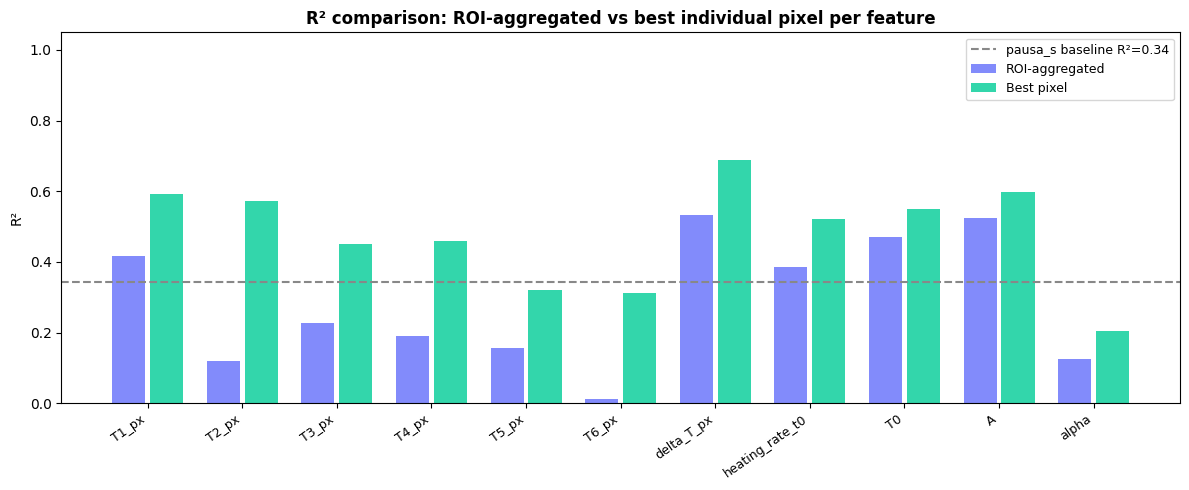


Comparison summary:
        feature  ROI_r2  best_pixel_r2  delta  best_pixel_id
          T1_px   0.416          0.591  0.175              9
          T2_px   0.119          0.572  0.454              9
          T3_px   0.228          0.452  0.224              8
          T4_px   0.190          0.458  0.268              9
          T5_px   0.155          0.321  0.166              8
          T6_px   0.012          0.311  0.299              9
     delta_T_px   0.532          0.689  0.157              0
heating_rate_t0   0.385          0.520  0.135              7
             T0   0.471          0.551  0.080              8
              A   0.525          0.598  0.073              0
          alpha   0.125          0.204  0.079              2


In [27]:
# ── Compare best pixel vs ROI-aggregated on same features ────────────────────
df_roi_paused = df_roi[df_roi['specimen'].str.contains('std', case=False) == False].copy()
if 'fit_ok' in df_roi_paused.columns:
    df_roi_paused = df_roi_paused[df_roi_paused['fit_ok'] == True].copy()

ROI_FEAT_MAP = {
    'T1_px': 'T1', 'T2_px': 'T2', 'T3_px': 'T3',
    'T4_px': 'T4', 'T5_px': 'T5', 'T6_px': 'T6',
    'delta_T_px': 'delta_T',
    'heating_rate_t0': 'heating_rate_t0',
    'T0': 'T0', 'A': 'A', 'alpha': 'alpha',
}

roi_r2 = {}
for px_feat, roi_feat in ROI_FEAT_MAP.items():
    if roi_feat not in df_roi_paused.columns:
        continue
    valid = df_roi_paused[['peso_rottura_kg', roi_feat]].dropna()
    if len(valid) < 3:
        continue
    X = valid[[roi_feat]].values
    y = valid['peso_rottura_kg'].values
    roi_r2[px_feat] = r2_score(y, LinearRegression().fit(X, y).predict(X))

best_px_r2   = {feat: r2_matrix[feat].max() for feat in ROI_FEAT_MAP if feat in r2_matrix.columns}
feats_common = [f for f in ROI_FEAT_MAP if f in roi_r2 and f in best_px_r2]
x_pos        = np.arange(len(feats_common))
roi_vals     = [roi_r2[f] for f in feats_common]
px_vals      = [best_px_r2[f] for f in feats_common]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 0.2, roi_vals, 0.35, label='ROI-aggregated', color='#636EFA', alpha=0.8)
ax.bar(x_pos + 0.2, px_vals,  0.35, label='Best pixel',     color='#00CC96', alpha=0.8)
ax.axhline(r2_pausa_base, color=COLOR_CTRL, ls='--', lw=1.5,
           label=f'pausa_s baseline R²={r2_pausa_base:.2f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(feats_common, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('R²', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title('R² comparison: ROI-aggregated vs best individual pixel per feature',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S6_pixel_vs_roi_r2.png'),
            dpi=150, bbox_inches='tight')
plt.show()

summary = pd.DataFrame({
    'feature':        feats_common,
    'ROI_r2':         [round(v, 3) for v in roi_vals],
    'best_pixel_r2':  [round(v, 3) for v in px_vals],
    'delta':          [round(p - r, 3) for r, p in zip(roi_vals, px_vals)],
    'best_pixel_id':  [r2_matrix[f].idxmax() if f in r2_matrix.columns else None for f in feats_common],
})
print('\nComparison summary:')
print(summary.to_string(index=False))
summary.to_csv(os.path.join(OUTPUT_DIR, 'pixel_vs_roi_comparison.csv'), index=False)

## Section 6b — Scatter plots: best pixel vs ROI-aggregated
> Top-3 features by pixel R²: side-by-side scatter plot ROI (top row) vs best pixel (bottom row).

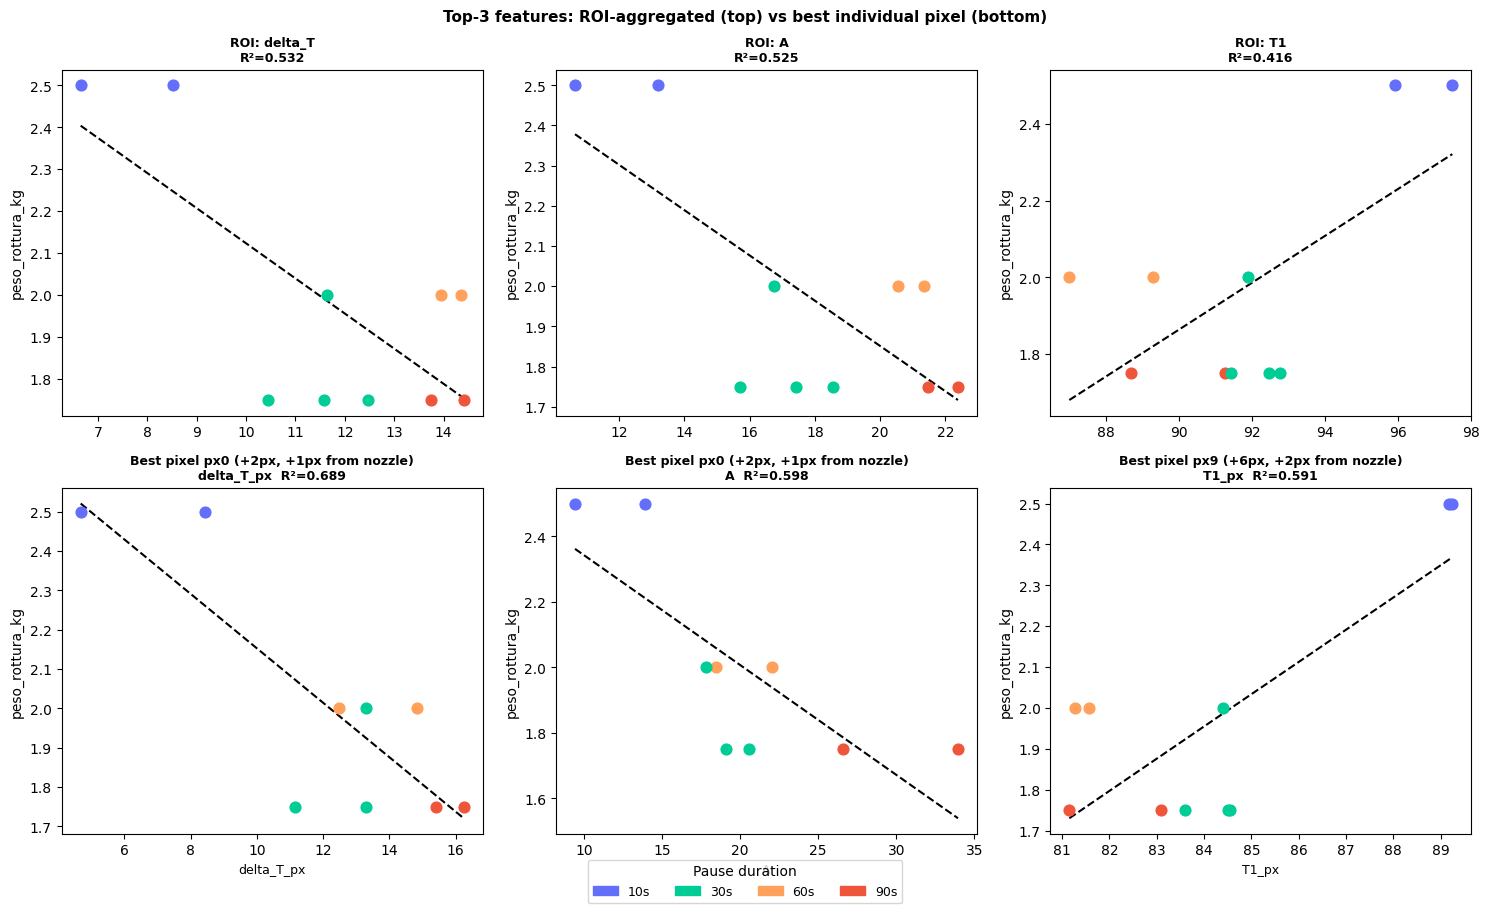

In [28]:
# ── Side-by-side scatter: top-3 features, ROI vs best pixel ──────────────────
top3_feats = sorted(best_px_r2, key=best_px_r2.get, reverse=True)[:3]

fig, axes = plt.subplots(2, len(top3_feats), figsize=(5 * len(top3_feats), 9))

for col_i, feat in enumerate(top3_feats):
    roi_feat = ROI_FEAT_MAP.get(feat, feat)
    best_pid = r2_matrix[feat].idxmax() if feat in r2_matrix.columns else None

    ax_top = axes[0, col_i]
    if roi_feat in df_roi_paused.columns:
        for _, row in df_roi_paused.iterrows():
            c = PAUSE_COLORS.get(int(row.get('pausa_s', 0)), '#999')
            ax_top.scatter(row[roi_feat], row['peso_rottura_kg'], color=c, s=60, zorder=3)
        valid = df_roi_paused[[roi_feat, 'peso_rottura_kg']].dropna()
        if len(valid) >= 2:
            xs  = np.linspace(valid[roi_feat].min(), valid[roi_feat].max(), 50)
            reg = LinearRegression().fit(valid[[roi_feat]], valid['peso_rottura_kg'])
            ax_top.plot(xs, reg.predict(xs.reshape(-1, 1)), 'k--', lw=1.5)
        ax_top.set_title(f'ROI: {roi_feat}\nR²={roi_r2.get(feat, 0):.3f}', fontweight='bold', fontsize=9)
    ax_top.set_ylabel('peso_rottura_kg')

    ax_bot = axes[1, col_i]
    if best_pid is not None:
        sub_px = df_px[df_px['pixel_id'] == best_pid]
        x_off  = WIDE_LEFT + (best_pid % n_cols)
        y_off  = DEPTH_TOP + (best_pid // n_cols)
        for _, row in sub_px.iterrows():
            c = PAUSE_COLORS.get(int(row.get('pausa_s', 0)), '#999')
            ax_bot.scatter(row[feat], row['peso_rottura_kg'], color=c, s=60, zorder=3)
        valid_px = sub_px[[feat, 'peso_rottura_kg']].dropna()
        if len(valid_px) >= 2:
            xs  = np.linspace(valid_px[feat].min(), valid_px[feat].max(), 50)
            reg = LinearRegression().fit(valid_px[[feat]], valid_px['peso_rottura_kg'])
            ax_bot.plot(xs, reg.predict(xs.reshape(-1, 1)), 'k--', lw=1.5)
        ax_bot.set_title(
            f'Best pixel px{best_pid} (+{x_off}px, +{y_off}px from nozzle)\n{feat}  R²={best_px_r2.get(feat,0):.3f}',
            fontweight='bold', fontsize=9)
    ax_bot.set_ylabel('peso_rottura_kg')
    ax_bot.set_xlabel(feat, fontsize=9)

handles = [mpatches.Patch(color=v, label=f'{k}s') for k, v in PAUSE_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), title='Pause duration')
fig.suptitle('Top-3 features: ROI-aggregated (top) vs best individual pixel (bottom)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'S6b_scatter_roi_vs_best_pixel.png'),
            dpi=150, bbox_inches='tight')
plt.show()